# Early Student Dropout Risk Classification

This project builds an early-warning model to identify students who may be at risk of dropping out. The aim is not to replace human judgement, but to support timely academic and counselling interventions.

**Dataset:** 649 Portuguese secondary school students with demographic, academic, family, and behavioural features. The target class is imbalanced, with about 15% of students labeled as dropped out.

**Goal:** Build a leakage-safe and explainable model that prioritises recall, gives calibrated risk scores, and highlights the main factors behind each high-risk prediction.


## Setup & Imports


In [150]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
from lime.lime_tabular import LimeTabularExplainer

print('All libraries loaded!')


All libraries loaded!


## 1. Load Data & Exploratory Analysis

The dataset is loaded from `student dropout.csv`. The first checks look at the class balance and the relationship between dropout status and key academic or behavioural variables.


In [151]:
data = pd.read_csv('student dropout.csv')
print(f'Shape: {data.shape}')
data.head()

Shape: (649, 34)


,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


Total : 649   Dropped out: 100 (15.4%)   Not dropped: 549 (84.6%)


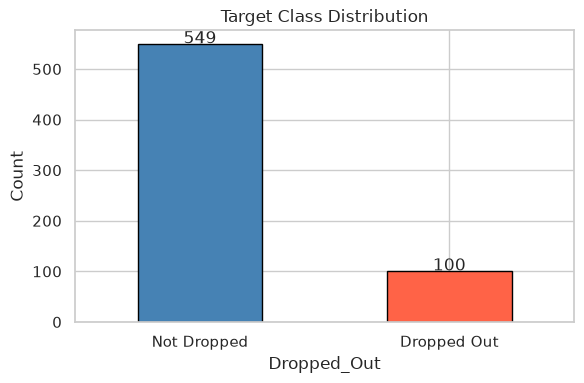

In [152]:
counts       = data['Dropped_Out'].value_counts()
dropout_rate = counts[True] / len(data) * 100
print(f'Total : {len(data)}   Dropped out: {counts[True]} ({dropout_rate:.1f}%)   Not dropped: {counts[False]} ({100-dropout_rate:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['Not Dropped', 'Dropped Out'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()+2), ha='center')
plt.tight_layout()
plt.show()

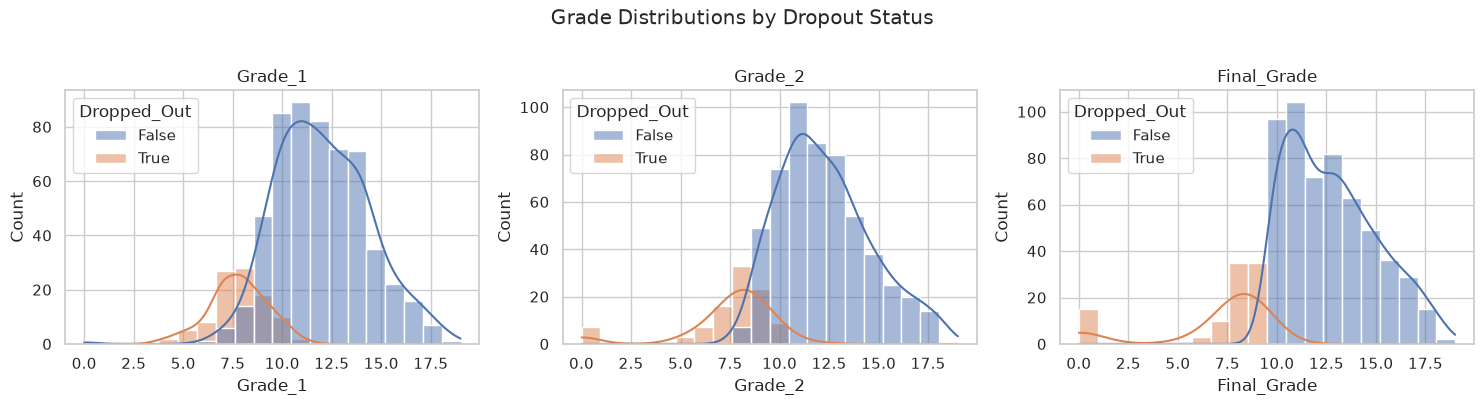

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Grade_1', 'Grade_2', 'Final_Grade']):
    sns.histplot(data=data, x=col, hue='Dropped_Out', bins=20, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Grade Distributions by Dropout Status', y=1.01)
plt.tight_layout()
plt.show()

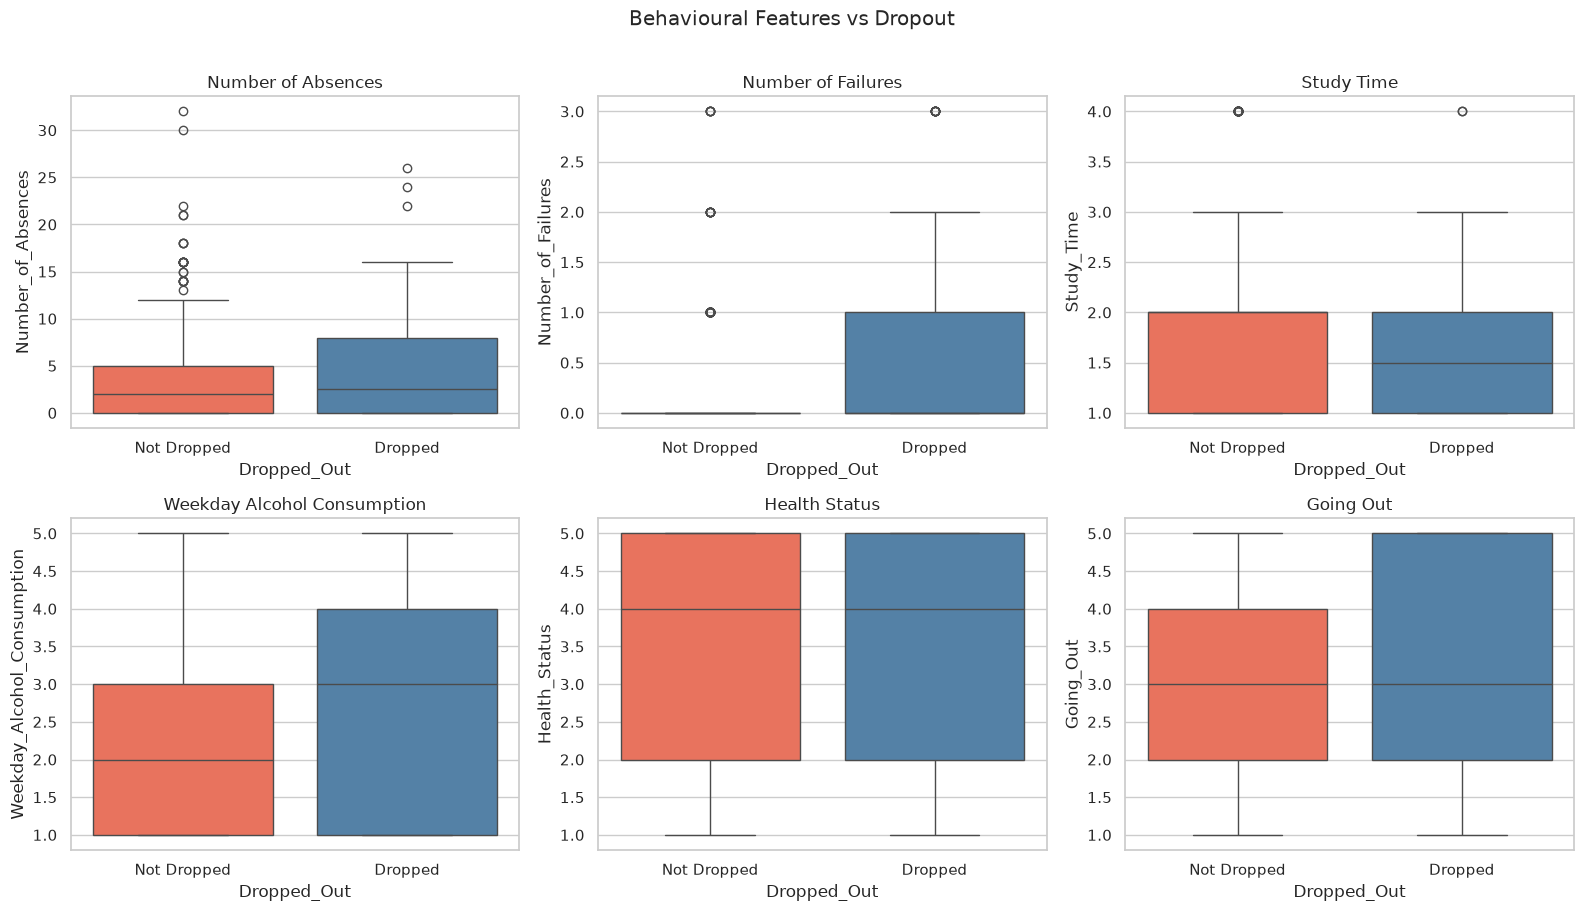

In [154]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['Number_of_Absences', 'Number_of_Failures', 'Study_Time',
            'Weekday_Alcohol_Consumption', 'Health_Status', 'Going_Out']

# newer seaborn serialises bool values as strings in the hue mapping
palette = {True: 'steelblue', False: 'tomato', 'True': 'steelblue', 'False': 'tomato'}

for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=data, x='Dropped_Out', y=feat, ax=ax, palette=palette)
    ax.set_xticklabels(['Not Dropped', 'Dropped'])
    ax.set_title(feat.replace('_', ' '))
plt.suptitle('Behavioural Features vs Dropout', y=1.01)
plt.tight_layout()
plt.show()

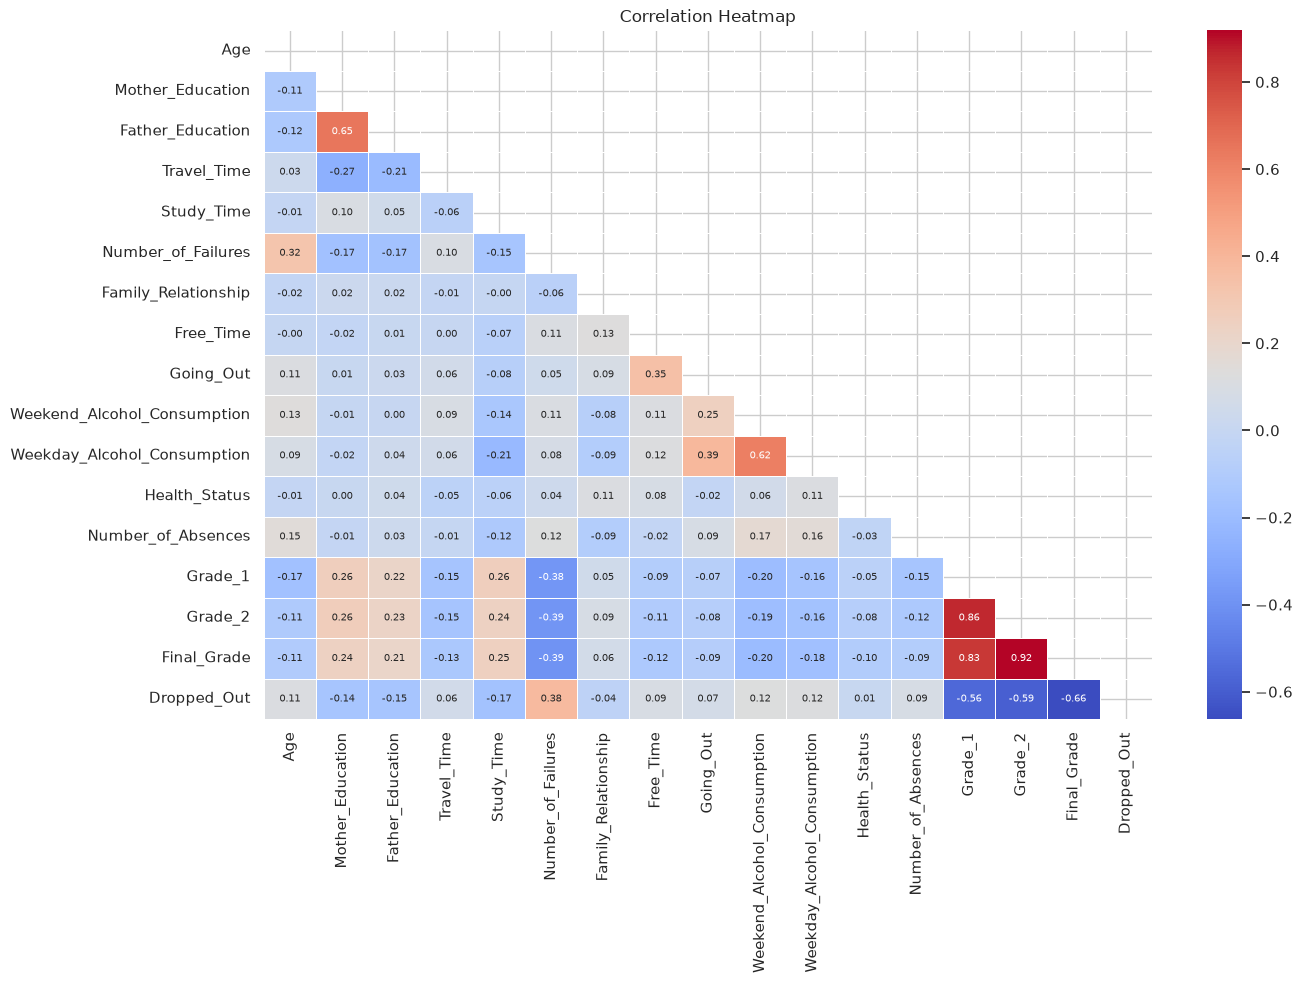

In [155]:
plt.figure(figsize=(14, 10))
numeric_data = data.select_dtypes(include=np.number).copy()
numeric_data['Dropped_Out'] = data['Dropped_Out'].astype(int)
mask = np.triu(np.ones_like(numeric_data.corr(), dtype=bool))
sns.heatmap(numeric_data.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 2. Data Leakage Investigation

The baseline model showed unusually high accuracy, indicating possible data leakage. Further investigation showed that every student with `Final_Grade = 0` is labeled as dropped out. However, not every dropped-out student has `Final_Grade = 0`; only a subset of dropout cases has zero final grade.

Therefore, `Final_Grade` is removed because it is recorded after the prediction point and directly leaks target information for some students. `Grade_1` and `Grade_2` are kept because they are available earlier and can act as legitimate early warning signals.


In [156]:
zero_grade = data[data['Final_Grade'] == 0]
dropouts   = data[data['Dropped_Out'] == True]
print(f'Students with Final_Grade=0          : {len(zero_grade)}')
print(f'Of those, who dropped out            : {zero_grade["Dropped_Out"].sum()} ({zero_grade["Dropped_Out"].mean()*100:.1f}%)')
print(f'Among dropouts, fraction with grade=0: {(dropouts["Final_Grade"]==0).mean()*100:.1f}%')
print('\nConclusion: Final_Grade is a near-perfect proxy for Dropped_Out → REMOVE IT')

Students with Final_Grade=0          : 15
Of those, who dropped out            : 15 (100.0%)
Among dropouts, fraction with grade=0: 15.0%

Conclusion: Final_Grade is a near-perfect proxy for Dropped_Out → REMOVE IT


## 3. Feature Engineering

Six derived features are kept for modelling. They are designed to capture academic performance, attendance-related risk, family education background, and study behaviour.

| Feature | What it captures |
|---|---|
| `Grade_Trend` | Change from first-period grade to second-period grade |
| `Low_Grade_Flag` | Whether the student scored 5 or below in either early grade |
| `Total_Alcohol` | Combined weekday and weekend alcohol consumption |
| `Max_Parent_Edu` | Highest education level among the two parents |
| `Academic_Risk` | Combined risk from failures and absences |
| `Study_Efficiency` | Study time adjusted for attendance pattern |

`Grade_Avg` is created only as an intermediate feature for `Study_Efficiency`. It is not used in the final model because it is directly derived from `Grade_1` and `Grade_2`.


In [157]:

def engineer_features(df):
    df = df.copy()
    df['Grade_Avg']        = (df['Grade_1'] + df['Grade_2']) / 2
    df['Grade_Trend']      = df['Grade_2'] - df['Grade_1']
    df['Low_Grade_Flag']   = ((df['Grade_1'] <= 5) | (df['Grade_2'] <= 5)).astype(int)
    df['Total_Alcohol']    = df['Weekend_Alcohol_Consumption'] + df['Weekday_Alcohol_Consumption']
    df['Max_Parent_Edu']   = df[['Mother_Education', 'Father_Education']].max(axis=1)
    df['Academic_Risk']    = df['Number_of_Failures'] * 3 + df['Number_of_Absences'] / 5.0
    df['Study_Efficiency'] = df['Grade_Avg'] / (df['Study_Time'] + 1e-3)
    return df

data = engineer_features(data)
new_feats = ['Grade_Avg', 'Grade_Trend', 'Low_Grade_Flag',
             'Total_Alcohol', 'Max_Parent_Edu', 'Academic_Risk', 'Study_Efficiency']
print(f'Shape after feature engineering: {data.shape}')
data[new_feats].describe().round(2)


Shape after feature engineering: (649, 41)


,Grade_Avg,Grade_Trend,Low_Grade_Flag,Total_Alcohol,Max_Parent_Edu,Academic_Risk,Study_Efficiency
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,11.48,0.17,0.02,3.78,2.71,1.40,6.98
std,2.73,1.48,0.15,1.99,1.08,2.11,3.16
min,2.00,-9.00,0.00,2.00,0.00,0.00,1.25
25%,9.50,-1.00,0.00,2.00,2.00,0.00,4.67
50%,11.50,0.00,0.00,3.00,3.00,0.60,6.25
75%,13.50,1.00,0.00,5.00,4.00,1.60,8.99
max,18.50,11.00,1.00,10.00,4.00,11.80,17.98


## 4. Preprocessing

The target, leakage column, and redundant engineered column are removed before modelling. Categorical variables are one-hot encoded and numerical variables are scaled inside the pipeline, so preprocessing is fitted separately within each cross-validation fold.


In [158]:

# Drop only: Final_Grade (leakage) + Grade_Avg (redundant — Grade_1 & Grade_2 are kept,
# the model learns their average relationship directly; Grade_Avg = (G1+G2)/2 adds nothing new)
X = data.drop(columns=['Dropped_Out', 'Final_Grade', 'Grade_Avg'])
y = data['Dropped_Out'].astype(int)

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include=np.number).columns.tolist()

print(f'Total features: {X.shape[1]}  |  Categorical: {len(categorical_cols)}  |  Numerical: {len(numerical_cols)}')
print(f'Dropout rate  : {y.mean()*100:.1f}%')
print(f'\nFeatures used:')
for f in X.columns.tolist(): print(f'  {f}')


Total features: 38  |  Categorical: 17  |  Numerical: 21
Dropout rate  : 15.4%

Features used:
  School
  Gender
  Age
  Address
  Family_Size
  Parental_Status
  Mother_Education
  Father_Education
  Mother_Job
  Father_Job
  Reason_for_Choosing_School
  Guardian
  Travel_Time
  Study_Time
  Number_of_Failures
  School_Support
  Family_Support
  Extra_Paid_Class
  Extra_Curricular_Activities
  Attended_Nursery
  Wants_Higher_Education
  Internet_Access
  In_Relationship
  Family_Relationship
  Free_Time
  Going_Out
  Weekend_Alcohol_Consumption
  Weekday_Alcohol_Consumption
  Health_Status
  Number_of_Absences
  Grade_1
  Grade_2
  Grade_Trend
  Low_Grade_Flag
  Total_Alcohol
  Max_Parent_Edu
  Academic_Risk
  Study_Efficiency


In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Train: 519  |  Test: 130


In [160]:

preprocessor = ColumnTransformer(transformers=[
    ('ohe',    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
    ('scaler', StandardScaler(), numerical_cols)
])

# Integer indices of categorical columns in X — required by SMOTENC
# SMOTENC needs to know which columns are categorical BEFORE one-hot encoding
cat_indices = [list(X.columns).index(col) for col in categorical_cols]

print(f'Preprocessor defined — will be fitted inside pipeline')
print(f'Categorical column indices for SMOTENC: {len(cat_indices)} columns')
print(f'Numerical columns                      : {len(numerical_cols)} columns')
print(f'\nCorrect order: SMOTENC (on raw data) → OHE/Scale → Model')
print(f'Old (wrong)  : OHE/Scale → SMOTE (interpolates binary OHE columns)')


Preprocessor defined — will be fitted inside pipeline
Categorical column indices for SMOTENC: 17 columns
Numerical columns                      : 21 columns

Correct order: SMOTENC (on raw data) → OHE/Scale → Model
Old (wrong)  : OHE/Scale → SMOTE (interpolates binary OHE columns)


## 5. Base Model Screening

The first modelling step compares several base classifiers using the same preprocessing and no special imbalance handling. This step is used only to shortlist the two strongest model families.

The main metric is **F2-score**. This gives more weight to recall, which is appropriate here because missing a student who may drop out is more costly than raising an extra alert.


In [161]:

from sklearn.metrics import make_scorer, fbeta_score

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODEL_NAMES = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
]

CLASS_WEIGHT_MODELS = {'Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'}

def build_classifier(model_name, imbalance='none', params=None):
    params = dict(params or {})
    use_weight = 'class_weight' in imbalance

    if model_name == 'Logistic Regression':
        return LogisticRegression(
            max_iter=1000,
            class_weight='balanced' if use_weight else None,
            **params
        )

    if model_name == 'Decision Tree':
        return DecisionTreeClassifier(
            max_depth=params.pop('max_depth', 5),
            class_weight='balanced' if use_weight else None,
            random_state=42,
            **params
        )

    if model_name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=params.pop('n_estimators', 100),
            class_weight='balanced' if use_weight else None,
            random_state=42,
            n_jobs=-1,
            **params
        )

    if model_name == 'Gradient Boosting':
        return GradientBoostingClassifier(
            n_estimators=params.pop('n_estimators', 100),
            random_state=42,
            **params
        )

    if model_name == 'XGBoost':
        return XGBClassifier(
            n_estimators=params.pop('n_estimators', 100),
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=pos_weight if use_weight else 1,
            n_jobs=-1,
            **params
        )

    raise ValueError(f'Unknown model: {model_name}')

def build_model_pipeline(model_name, imbalance='none', params=None):
    steps = []
    if 'SMOTENC' in imbalance:
        steps.append(('smotenc', SMOTENC(categorical_features=cat_indices, random_state=42)))

    steps.extend([
        ('preprocessor', clone(preprocessor)),
        ('clf', build_classifier(model_name, imbalance=imbalance, params=params)),
    ])
    return ImbPipeline(steps)

base_cv_results = {}
base_rows = []

for model_name in MODEL_NAMES:
    pipe = build_model_pipeline(model_name, imbalance='none')
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
    base_cv_results[model_name] = scores
    base_rows.append({
        'Model': model_name,
        'Mean F2': scores.mean(),
        'Std F2': scores.std(),
    })
    print(f'{model_name:22s}  F2={scores.mean():.4f}  +/-{scores.std():.4f}')

base_summary = pd.DataFrame(base_rows).sort_values('Mean F2', ascending=False)
top_two_models = base_summary.head(2)['Model'].tolist()

print('\nTop two base models selected for imbalance comparison:')
for i, model_name in enumerate(top_two_models, start=1):
    print(f'{i}. {model_name}')


Logistic Regression     F2=0.6866  +/-0.1169
Decision Tree           F2=0.6934  +/-0.0893
Random Forest           F2=0.7183  +/-0.1320
Gradient Boosting       F2=0.6751  +/-0.1161
XGBoost                 F2=0.7549  +/-0.0977

Top two base models selected for imbalance comparison:
1. XGBoost
2. Random Forest


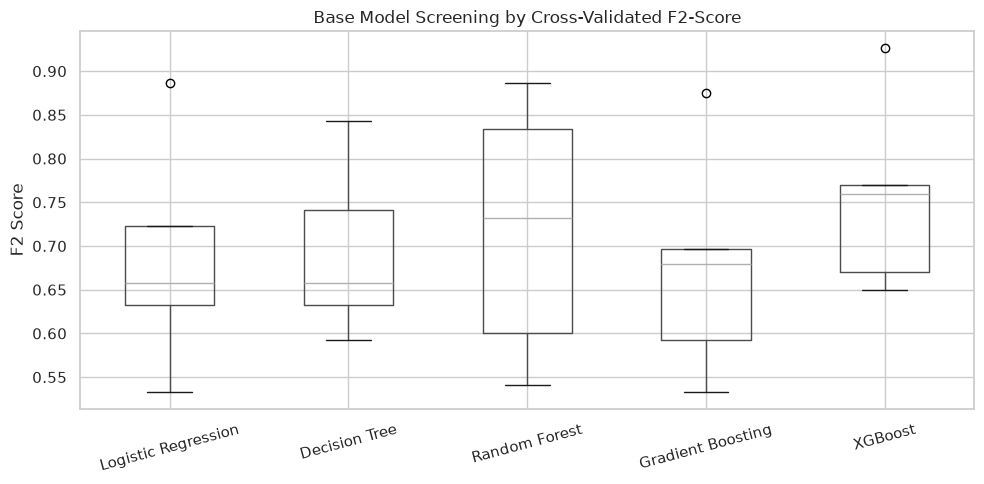

,Model,Mean F2,Std F2
4,XGBoost,0.7549,0.0977
2,Random Forest,0.7183,0.1320
1,Decision Tree,0.6934,0.0893
0,Logistic Regression,0.6866,0.1169
3,Gradient Boosting,0.6751,0.1161


In [162]:

cv_df = pd.DataFrame(base_cv_results)
fig, ax = plt.subplots(figsize=(10, 5))
cv_df.boxplot(ax=ax)
ax.set_title('Base Model Screening by Cross-Validated F2-Score')
ax.set_ylabel('F2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(base_summary.round(4))


## 6. Imbalance Handling for the Top Two Models

Only the two strongest base models are carried forward. For each one, imbalance handling is tested as part of the full pipeline:

- no imbalance handling
- class weighting, where supported
- SMOTENC before one-hot encoding
- SMOTENC plus class weighting, where supported

This keeps model selection consistent: the chosen option is the best complete pipeline, not a model selected separately from its imbalance strategy.


XGBoost + none                                 F2=0.7549  +/-0.0977
XGBoost + class_weight                         F2=0.7786  +/-0.0908
XGBoost + SMOTENC                              F2=0.7677  +/-0.1024
XGBoost + SMOTENC + class_weight               F2=0.7738  +/-0.0968
Random Forest + none                           F2=0.7183  +/-0.1320
Random Forest + class_weight                   F2=0.8065  +/-0.1077
Random Forest + SMOTENC                        F2=0.7687  +/-0.1103
Random Forest + SMOTENC + class_weight         F2=0.7319  +/-0.1062

Best complete pipeline:
Random Forest + class_weight  (CV F2=0.8065)


,Model,Imbalance,Mean F2,Std F2
5,Random Forest,class_weight,0.8065,0.1077
1,XGBoost,class_weight,0.7786,0.0908
3,XGBoost,SMOTENC + class_weight,0.7738,0.0968
6,Random Forest,SMOTENC,0.7687,0.1103
2,XGBoost,SMOTENC,0.7677,0.1024
0,XGBoost,none,0.7549,0.0977
7,Random Forest,SMOTENC + class_weight,0.7319,0.1062
4,Random Forest,none,0.7183,0.1320


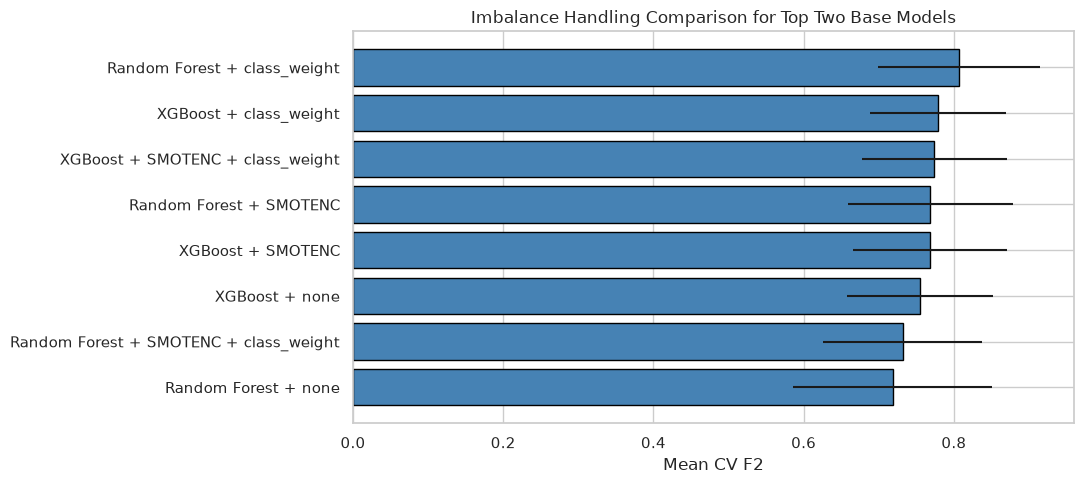

In [163]:

imbalance_options = ['none', 'class_weight', 'SMOTENC', 'SMOTENC + class_weight']
imbalance_rows = []
imbalance_results = {}

for model_name in top_two_models:
    for imbalance in imbalance_options:
        if 'class_weight' in imbalance and model_name not in CLASS_WEIGHT_MODELS:
            continue

        pipe = build_model_pipeline(model_name, imbalance=imbalance)
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
        key = f'{model_name} + {imbalance}'
        imbalance_results[key] = scores
        imbalance_rows.append({
            'Model': model_name,
            'Imbalance': imbalance,
            'Mean F2': scores.mean(),
            'Std F2': scores.std(),
        })
        print(f'{key:45s}  F2={scores.mean():.4f}  +/-{scores.std():.4f}')

imbalance_summary = pd.DataFrame(imbalance_rows).sort_values('Mean F2', ascending=False)
best_selection = imbalance_summary.iloc[0]
selected_model_name = best_selection['Model']
selected_imbalance = best_selection['Imbalance']

print('\nBest complete pipeline:')
print(f'{selected_model_name} + {selected_imbalance}  (CV F2={best_selection["Mean F2"]:.4f})')

display(imbalance_summary.round(4))

plot_df = imbalance_summary.copy()
plot_df['Pipeline'] = plot_df['Model'] + ' + ' + plot_df['Imbalance']
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(plot_df['Pipeline'], plot_df['Mean F2'], xerr=plot_df['Std F2'], color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('Mean CV F2')
ax.set_title('Imbalance Handling Comparison for Top Two Base Models')
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning with Optuna

The selected complete pipeline is tuned with Optuna. This avoids tuning models that were not selected by the earlier validation process and keeps the workflow focused on the best candidate.


In [164]:

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def sample_params(trial, model_name):
    if model_name == 'Logistic Regression':
        return {
            'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        }

    if model_name == 'Decision Tree':
        return {
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        }

    if model_name == 'Random Forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_float('max_features', 0.2, 0.9),
        }

    if model_name == 'Gradient Boosting':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }

    if model_name == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'gamma': trial.suggest_float('gamma', 0.0, 0.5),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 4.0),
        }

    return {}

def objective(trial):
    params = sample_params(trial, selected_model_name)
    pipe = build_model_pipeline(selected_model_name, imbalance=selected_imbalance, params=params)
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
print(f'Tuning {selected_model_name} + {selected_imbalance} — 60 trials...')
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_tuned_model_name = selected_model_name
best_tuned_imbalance = selected_imbalance
best_tuned_params = study.best_params
best_tuned_cv_f2 = study.best_value

print(f'Best tuned pipeline: {best_tuned_model_name} + {best_tuned_imbalance}')
print(f'Best CV F2: {best_tuned_cv_f2:.4f}')
print(f'Best params: {best_tuned_params}')


Tuning Random Forest + class_weight — 60 trials...


Best trial: 41. Best value: 0.867398: 100%|██████████| 60/60 [01:04<00:00,  1.07s/it]

Best tuned pipeline: Random Forest + class_weight
Best CV F2: 0.8674
Best params: {'n_estimators': 400, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.2049021294945219}


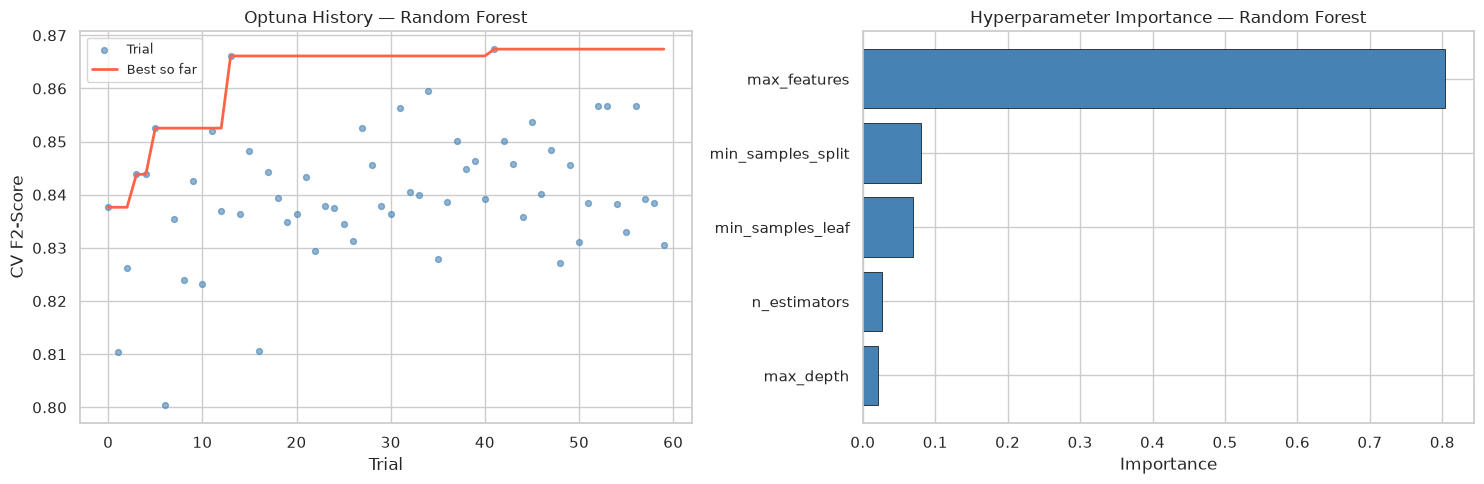

In [165]:

from optuna.importance import get_param_importances

trials = [t for t in study.trials if t.value is not None]
nums = [t.number for t in trials]
values = [t.value for t in trials]
best_so_far = [max(values[:i + 1]) for i in range(len(values))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(nums, values, s=18, alpha=0.6, color='steelblue', label='Trial')
axes[0].plot(nums, best_so_far, color='tomato', linewidth=2, label='Best so far')
axes[0].set_title(f'Optuna History — {best_tuned_model_name}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV F2-Score')
axes[0].legend(fontsize=9)

importance = get_param_importances(study)
if importance:
    params = list(importance.keys())
    scores = list(importance.values())
    order = sorted(range(len(scores)), key=lambda i: scores[i])
    params = [params[i] for i in order]
    scores = [scores[i] for i in order]

    axes[1].barh(params, scores, color='steelblue', edgecolor='black', linewidth=0.5)
    axes[1].set_title(f'Hyperparameter Importance — {best_tuned_model_name}')
    axes[1].set_xlabel('Importance')
else:
    axes[1].text(0.5, 0.5, 'No parameter importance available', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## 8. Final Model Evaluation + Threshold Tuning

The tuned pipeline is fitted on the training data and evaluated on the test set. A separate validation split from the training data is used to choose an F2-focused decision threshold.

The default threshold of 0.50 is shown for reference, but the selected threshold is the one that gives the best validation F2-score.


In [166]:

final_pipeline = build_model_pipeline(
    best_tuned_model_name,
    imbalance=best_tuned_imbalance,
    params=best_tuned_params
)

print('Final tuned pipeline:')
print(f'  Model     : {best_tuned_model_name}')
print(f'  Imbalance : {best_tuned_imbalance}')
print(f'  CV F2     : {best_tuned_cv_f2:.4f}')

final_pipeline.fit(X_train, y_train)
final_model = final_pipeline.named_steps['clf']
winner_name = best_tuned_model_name

# Extract preprocessed versions for SHAP and LIME.
X_train_proc = final_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_proc = final_pipeline.named_steps['preprocessor'].transform(X_test)
feature_names = [f.replace('ohe__', '').replace('scaler__', '')
                 for f in final_pipeline.named_steps['preprocessor'].get_feature_names_out()]

y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

print(f'\n{winner_name} (Optuna-tuned) — test set:')
print(classification_report(y_test, y_pred, target_names=['Not Dropped', 'Dropped Out']))
print(f'ROC-AUC         : {roc_auc_score(y_test, y_prob):.4f}')
print(f'FN (missed)     : {((y_test==1)&(y_pred==0)).sum()}')


Final tuned pipeline:
  Model     : Random Forest
  Imbalance : class_weight
  CV F2     : 0.8674

Random Forest (Optuna-tuned) — test set:
              precision    recall  f1-score   support

 Not Dropped       0.97      0.85      0.91       110
 Dropped Out       0.52      0.85      0.64        20

    accuracy                           0.85       130
   macro avg       0.74      0.85      0.77       130
weighted avg       0.90      0.85      0.87       130

ROC-AUC         : 0.9491
FN (missed)     : 3


Threshold selected on validation set (n=104): 0.56

Evaluated on test set:
  Default (thr=0.50) → FN=3  Prec=0.515  Rec=0.850
  F2-opt  (thr=0.56) → FN=3  Prec=0.515  Rec=0.850

  → 0 fewer missed dropouts


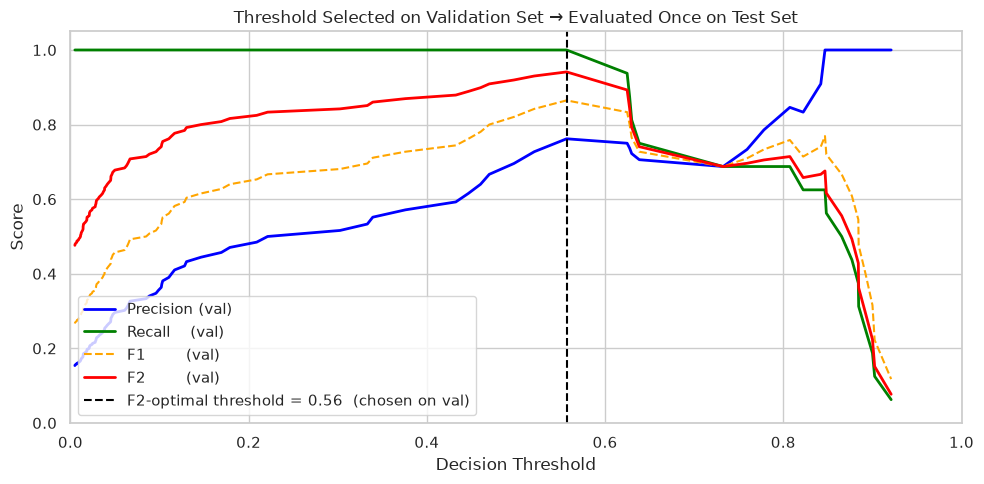

In [167]:

X_tr_val, X_val, y_tr_val, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
)

_val_pipe = clone(final_pipeline)
_val_pipe.fit(X_tr_val, y_tr_val)
y_prob_val = _val_pipe.predict_proba(X_val)[:, 1]

prec_val, rec_val, thr_arr = precision_recall_curve(y_val, y_prob_val)
beta   = 2
f2_arr = np.where((beta**2 * prec_val + rec_val) > 0,
                   (1 + beta**2) * prec_val * rec_val / (beta**2 * prec_val + rec_val), 0)
f1_arr = np.where((prec_val + rec_val) > 0,
                   2 * prec_val * rec_val / (prec_val + rec_val), 0)
best_idx = int(np.argmax(f2_arr[:-1]))
best_thr = float(thr_arr[best_idx])

y_pred_tuned = (y_prob >= best_thr).astype(int)

fn_default = int(((y_test==1) & (y_pred==0)).sum())
fn_tuned   = int(((y_test==1) & (y_pred_tuned==0)).sum())

print(f'Threshold selected on validation set (n={len(y_val)}): {best_thr:.2f}')
print(f'\nEvaluated on test set:')
print(f'  Default (thr=0.50) → FN={fn_default}  '
      f'Prec={precision_score(y_test, y_pred,       zero_division=0):.3f}  '
      f'Rec={recall_score(y_test, y_pred):.3f}')
print(f'  F2-opt  (thr={best_thr:.2f}) → FN={fn_tuned}  '
      f'Prec={precision_score(y_test, y_pred_tuned, zero_division=0):.3f}  '
      f'Rec={recall_score(y_test, y_pred_tuned):.3f}')
print(f'\n  → {fn_default - fn_tuned} fewer missed dropouts')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_arr, prec_val[:-1], label='Precision (val)', color='blue',   linewidth=2)
ax.plot(thr_arr, rec_val[:-1],  label='Recall    (val)', color='green',  linewidth=2)
ax.plot(thr_arr, f1_arr[:-1],   label='F1        (val)', color='orange', linewidth=1.5, linestyle='--')
ax.plot(thr_arr, f2_arr[:-1],   label='F2        (val)', color='red',    linewidth=2)
ax.axvline(best_thr, linestyle='--', color='black', linewidth=1.5,
           label=f'F2-optimal threshold = {best_thr:.2f}  (chosen on val)')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Selected on Validation Set → Evaluated Once on Test Set')
ax.legend(loc='lower left'); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()


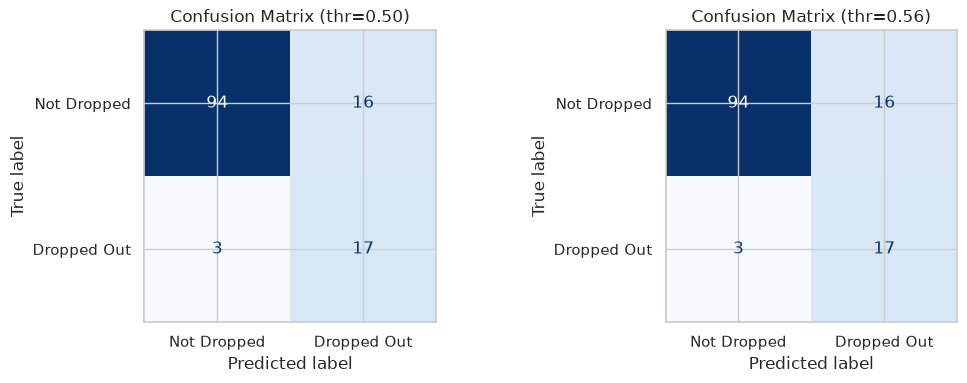

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_p, title in zip(axes,
                          [y_pred, y_pred_tuned],
                          ['Confusion Matrix (thr=0.50)', f'Confusion Matrix (thr={best_thr:.2f})']):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_p),
        display_labels=['Not Dropped', 'Dropped Out']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

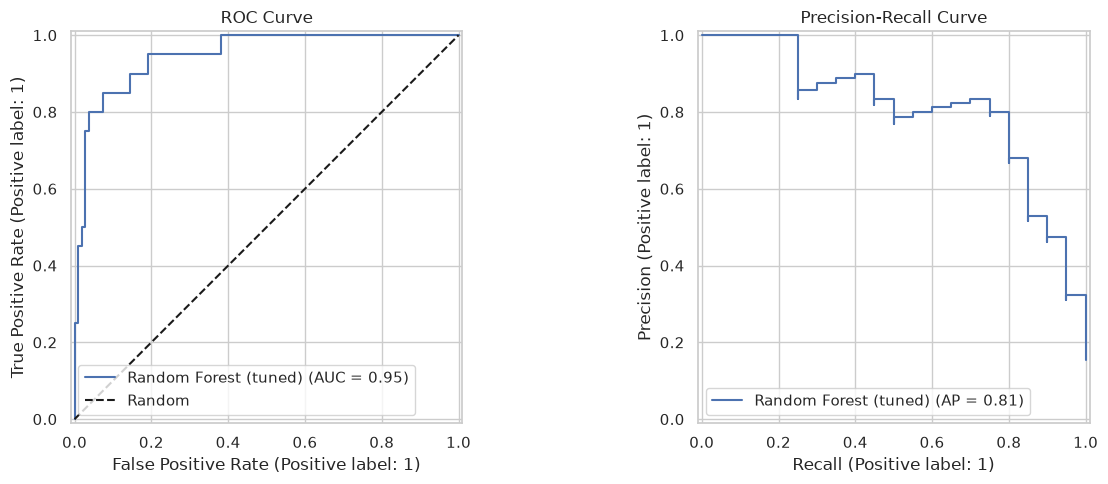

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, name=f'{winner_name} (tuned)', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', label='Random'); axes[0].set_title('ROC Curve'); axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=f'{winner_name} (tuned)', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()

## 9. Fairness Analysis

Overall recall can hide subgroup differences, so the final predictions are checked across gender, school, address, and age group. These results are diagnostic only; they are not used to tune the model.


     Group  N  Dropouts  Recall  Precision    F2  FN (missed)  FN Rate
 Gender: F 80        10   0.900      0.562 0.804            1    0.100
 Gender: M 50        10   0.800      0.471 0.702            2    0.200
School: GP 84         7   0.714      0.455 0.641            2    0.286
School: MS 46        13   0.923      0.545 0.811            1    0.077
Address: R 33         9   1.000      0.692 0.918            0    0.000
Address: U 97        11   0.727      0.400 0.625            3    0.273
Age: 15-17 90        12   0.833      0.500 0.735            2    0.167
Age: 18-19 37         8   0.875      0.636 0.814            1    0.125


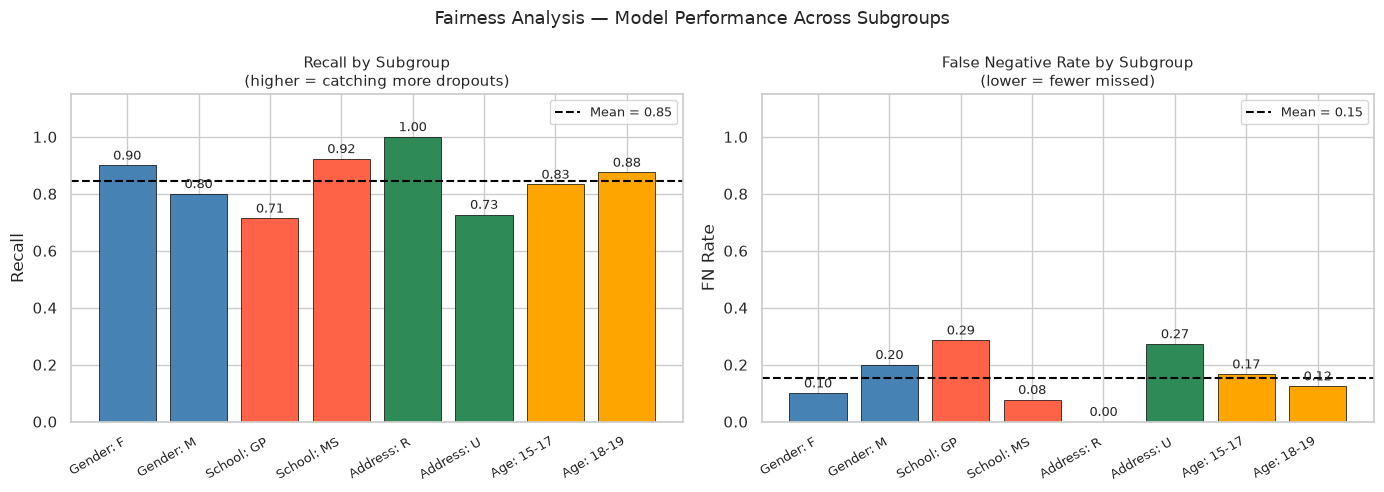


Recall gap  : 0.286  ⚠  Potential bias — investigate
FN Rate gap : 0.286  ⚠  Potential bias — investigate

Subgroups most at risk of being missed (highest FN Rate):
     Group  N  Dropouts  Recall  FN (missed)  FN Rate
School: GP 84         7   0.714            2    0.286
Address: U 97        11   0.727            3    0.273
 Gender: M 50        10   0.800            2    0.200


In [170]:

# ── Fairness / Subgroup Analysis ───────────────────────────────────────────────
X_test_r = X_test.reset_index(drop=True)
y_test_r = pd.Series(y_test.values)
y_pred_r = pd.Series(y_pred_tuned)

def grp_metrics(mask, label):
    yt, yp = y_test_r[mask], y_pred_r[mask]
    if yt.sum() == 0:
        return None
    fn = int(((yt==1) & (yp==0)).sum())
    return {
        'Group':       label,
        'N':           int(mask.sum()),
        'Dropouts':    int(yt.sum()),
        'Recall':      round(recall_score(yt, yp, zero_division=0), 3),
        'Precision':   round(precision_score(yt, yp, zero_division=0), 3),
        'F2':          round(fbeta_score(yt, yp, beta=2, zero_division=0), 3),
        'FN (missed)': fn,
        'FN Rate':     round(fn / yt.sum(), 3),
    }

rows = []

for v in sorted(X_test_r['Gender'].unique()):
    r = grp_metrics(X_test_r['Gender'] == v, f'Gender: {v}')
    if r: rows.append(r)

for v in sorted(X_test_r['School'].unique()):
    r = grp_metrics(X_test_r['School'] == v, f'School: {v}')
    if r: rows.append(r)

for v in sorted(X_test_r['Address'].unique()):
    r = grp_metrics(X_test_r['Address'] == v, f'Address: {v}')
    if r: rows.append(r)

age_labels = ['15-17', '18-19', '20+']
age_grp    = pd.cut(X_test_r['Age'], bins=[14, 17, 19, 25], labels=age_labels)
for v in age_labels:
    r = grp_metrics(age_grp == v, f'Age: {v}')
    if r: rows.append(r)

fair_df = pd.DataFrame(rows)
print(fair_df.to_string(index=False))

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = ['steelblue' if 'Gender'  in g else
           'tomato'    if 'School'  in g else
           'seagreen'  if 'Address' in g else
           'orange'    for g in fair_df['Group']]

for ax, metric, title in [
    (axes[0], 'Recall',   'Recall by Subgroup\n(higher = catching more dropouts)'),
    (axes[1], 'FN Rate',  'False Negative Rate by Subgroup\n(lower = fewer missed)'),
]:
    bars = ax.bar(fair_df['Group'], fair_df[metric],
                  color=palette, edgecolor='black', linewidth=0.5)
    ax.axhline(fair_df[metric].mean(), color='black', linewidth=1.5,
               linestyle='--', label=f'Mean = {fair_df[metric].mean():.2f}')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, fair_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle('Fairness Analysis — Model Performance Across Subgroups', fontsize=13)
plt.tight_layout()
plt.show()

# ── Bias flags ─────────────────────────────────────────────────────────────────
recall_gap = fair_df['Recall'].max() - fair_df['Recall'].min()
fnr_gap    = fair_df['FN Rate'].max() - fair_df['FN Rate'].min()

print(f'\nRecall gap  : {recall_gap:.3f}  '
      f'{"⚠  Potential bias — investigate" if recall_gap > 0.15 else "✓  Acceptable"}')
print(f'FN Rate gap : {fnr_gap:.3f}  '
      f'{"⚠  Potential bias — investigate" if fnr_gap > 0.15 else "✓  Acceptable"}')

print('\nSubgroups most at risk of being missed (highest FN Rate):')
print(fair_df.sort_values('FN Rate', ascending=False)
      [['Group','N','Dropouts','Recall','FN (missed)','FN Rate']]
      .head(3).to_string(index=False))


### Findings

The subgroup table should be read as a diagnostic check rather than final proof of bias. Some groups have only a small number of dropout cases, so their recall and false-negative rates can change noticeably with a few students.

Large recall or false-negative-rate gaps should be treated as signals for further review, especially before using the model in a real school setting.


> **Note on group-wise thresholds**
>
> The final system uses one global threshold. Group-specific thresholds were not applied because several subgroups have small dropout counts, and separate thresholds could overfit to validation noise.
>
> With a larger dataset, subgroup calibration and thresholding could be studied more carefully as future work.


## 10. Probability Calibration

The model's raw probabilities are calibrated using `CalibratedClassifierCV` with 5-fold Platt scaling. This fits the base pipeline on cross-validation folds and learns the Platt calibrator from held-out fold predictions — keeping calibration fitting and threshold selection fully independent (no double-dip on the same split).

The final calibrated model is fitted on all of `X_train`. A separate copy is fitted on `X_tr_val` only so that `X_val` is genuinely unseen when selecting `best_thr_cal`.

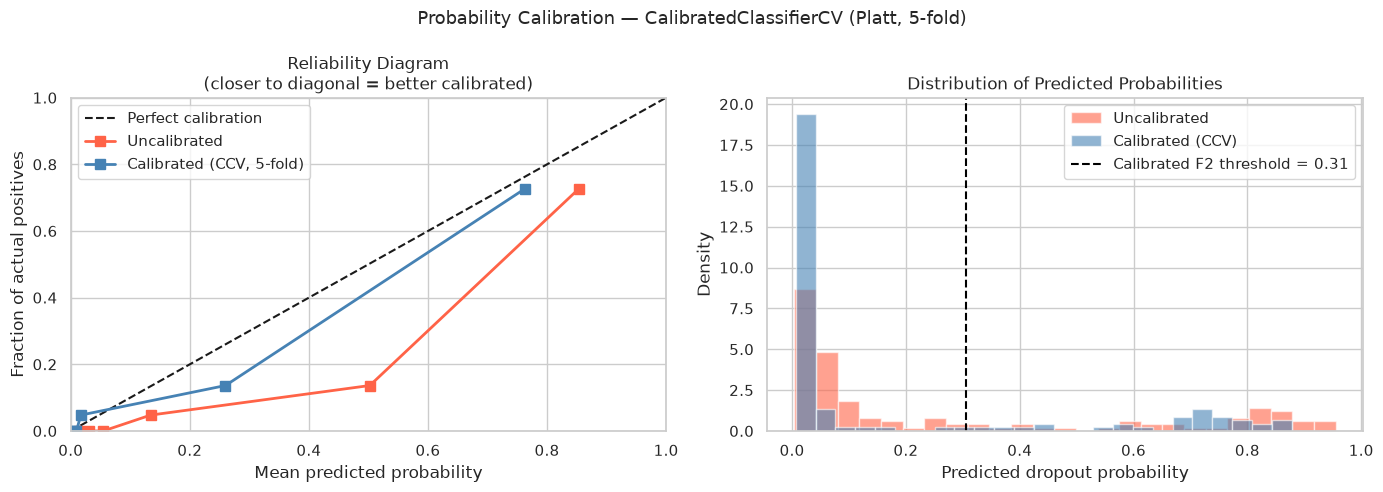

Brier Score — Uncalibrated : 0.0917
Brier Score — Calibrated   : 0.0686
Improvement                : 25.2%

Raw validation threshold         : 0.56
Calibrated threshold (on X_val)  : 0.31

Using calibrated threshold (0.31) on calibrated test probabilities:
  Recall    : 0.850  (raw-threshold model: 0.850)
  Precision : 0.548  (raw-threshold model: 0.515)
  F2        : 0.766  (raw-threshold model: 0.752)
  FN missed : 3  (raw-threshold model: 3)


In [171]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# ── Final calibrated model (all X_train, cv=5 cross-calibration) ─────────────
# CalibratedClassifierCV fits the pipeline on each of 5 CV folds and learns
# the Platt calibrator from the held-out predictions — no single split is used
# for both calibration fitting and threshold selection.
calibrated_pipeline = CalibratedClassifierCV(
    clone(final_pipeline), cv=5, method='sigmoid'
)
calibrated_pipeline.fit(X_train, y_train)
y_prob_cal = calibrated_pipeline.predict_proba(X_test)[:, 1]

# ── Threshold selection on X_val (calibrated model not trained on X_val) ─────
# Fit a separate calibrated model on X_tr_val only, then evaluate on X_val.
# X_tr_val and X_val were defined in Section 8.
_cal_thr = CalibratedClassifierCV(clone(final_pipeline), cv=5, method='sigmoid')
_cal_thr.fit(X_tr_val, y_tr_val)
y_prob_val_cal = _cal_thr.predict_proba(X_val)[:, 1]

prec_cal, rec_cal, thr_cal = precision_recall_curve(y_val, y_prob_val_cal)
beta = 2
f2_cal = np.where((beta**2 * prec_cal + rec_cal) > 0,
                  (1 + beta**2) * prec_cal * rec_cal / (beta**2 * prec_cal + rec_cal), 0)
best_idx_cal = int(np.argmax(f2_cal[:-1]))
best_thr_cal  = float(thr_cal[best_idx_cal])

y_pred_cal = (y_prob_cal >= best_thr_cal).astype(int)

# ── Reliability diagram ───────────────────────────────────────────────────────
frac_pos_u, mean_pred_u = calibration_curve(y_test, y_prob,     n_bins=6, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, y_prob_cal, n_bins=6, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Perfect calibration')
ax.plot(mean_pred_u, frac_pos_u, 's-', color='tomato',    linewidth=2, markersize=7, label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, 's-', color='steelblue', linewidth=2, markersize=7, label='Calibrated (CCV, 5-fold)')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of actual positives')
ax.set_title('Reliability Diagram\n(closer to diagonal = better calibrated)')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = axes[1]
ax.hist(y_prob,     bins=25, alpha=0.6, color='tomato',    density=True, label='Uncalibrated')
ax.hist(y_prob_cal, bins=25, alpha=0.6, color='steelblue', density=True, label='Calibrated (CCV)')
ax.axvline(best_thr_cal, color='black', linestyle='--', linewidth=1.5,
           label=f'Calibrated F2 threshold = {best_thr_cal:.2f}')
ax.set_xlabel('Predicted dropout probability'); ax.set_ylabel('Density')
ax.set_title('Distribution of Predicted Probabilities')
ax.legend()
plt.suptitle('Probability Calibration — CalibratedClassifierCV (Platt, 5-fold)', fontsize=13)
plt.tight_layout(); plt.show()

brier_u = brier_score_loss(y_test, y_prob)
brier_c = brier_score_loss(y_test, y_prob_cal)

print(f'Brier Score — Uncalibrated : {brier_u:.4f}')
print(f'Brier Score — Calibrated   : {brier_c:.4f}')
print(f'Improvement                : {(brier_u - brier_c)/brier_u * 100:.1f}%')

print(f'\nRaw validation threshold         : {best_thr:.2f}')
print(f'Calibrated threshold (on X_val)  : {best_thr_cal:.2f}')
print(f'\nUsing calibrated threshold ({best_thr_cal:.2f}) on calibrated test probabilities:')
print(f'  Recall    : {recall_score(y_test, y_pred_cal):.3f}  (raw-threshold model: {recall_score(y_test, y_pred_tuned):.3f})')
print(f'  Precision : {precision_score(y_test, y_pred_cal, zero_division=0):.3f}  (raw-threshold model: {precision_score(y_test, y_pred_tuned, zero_division=0):.3f})')
print(f'  F2        : {fbeta_score(y_test, y_pred_cal, beta=2, zero_division=0):.3f}  (raw-threshold model: {fbeta_score(y_test, y_pred_tuned, beta=2, zero_division=0):.3f})')
print(f'  FN missed : {int(((y_test==1)&(y_pred_cal==0)).sum())}  (raw-threshold model: {int(((y_test==1)&(y_pred_tuned==0)).sum())})')

## 11. Explainability — SHAP

SHAP is used to show how each feature contributes to a prediction. Positive SHAP values push the prediction toward dropout risk, while negative values reduce the predicted risk.

The explainer is chosen based on the final model type. If SHAP returns values for both classes, the dropout class is selected before plotting or ranking features.


In [172]:
X_train_df = pd.DataFrame(np.asarray(X_train_proc), columns=feature_names)
X_test_df = pd.DataFrame(np.asarray(X_test_proc), columns=feature_names)

if isinstance(final_model, LogisticRegression):
    explainer_shap = shap.LinearExplainer(final_model, X_train_df)
    shap_raw = explainer_shap(X_test_df)
elif isinstance(final_model, (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier, DecisionTreeClassifier)):
    explainer_shap = shap.TreeExplainer(final_model)
    shap_raw = explainer_shap(X_test_df)
else:
    explainer_shap = shap.Explainer(final_model.predict_proba, X_train_df)
    shap_raw = explainer_shap(X_test_df)

shap_value_array = np.asarray(shap_raw.values)
base_values = getattr(shap_raw, 'base_values', None)

# Some classifiers return SHAP values as samples x features x classes.
# Keep class 1, which is the dropout / at-risk class.
if shap_value_array.ndim == 3:
    shap_value_array = shap_value_array[:, :, 1]
    if base_values is not None:
        base_values = np.asarray(base_values)
        if base_values.ndim == 2:
            base_values = base_values[:, 1]

shap_values = shap.Explanation(
    values=shap_value_array,
    base_values=base_values,
    data=X_test_df.values,
    feature_names=feature_names,
)

print(f'SHAP values shape: {shap_values.values.shape}  (samples x features)')
print(f'Feature names     : {len(feature_names)}')


SHAP values shape: (130, 47)  (samples x features)
Feature names     : 47


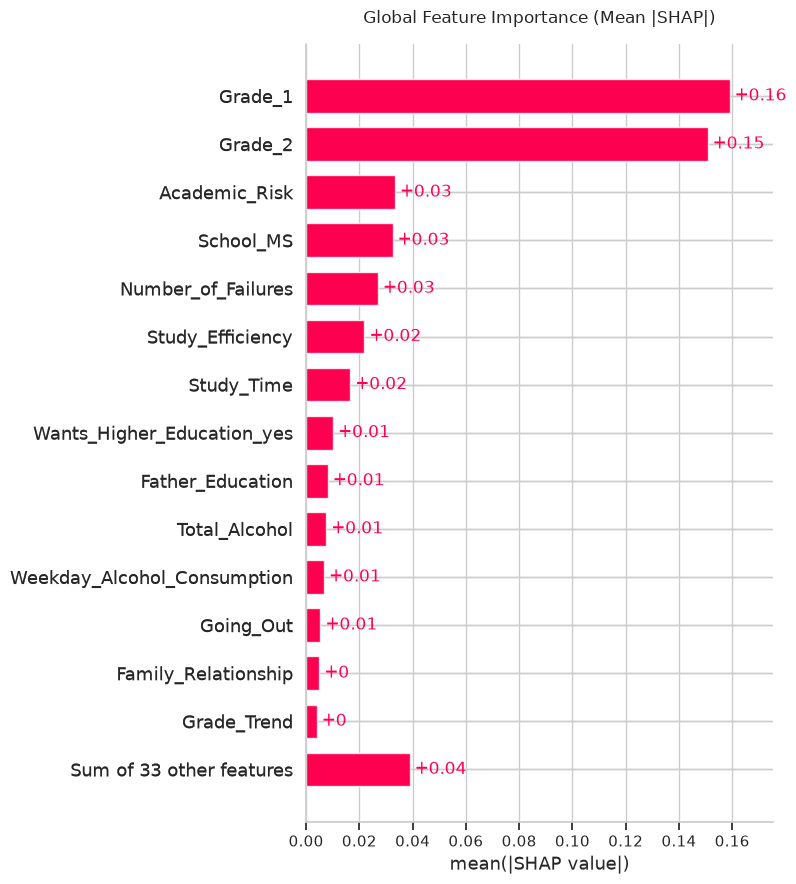

In [173]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Global Feature Importance (Mean |SHAP|)', pad=15)
plt.tight_layout()
plt.show()


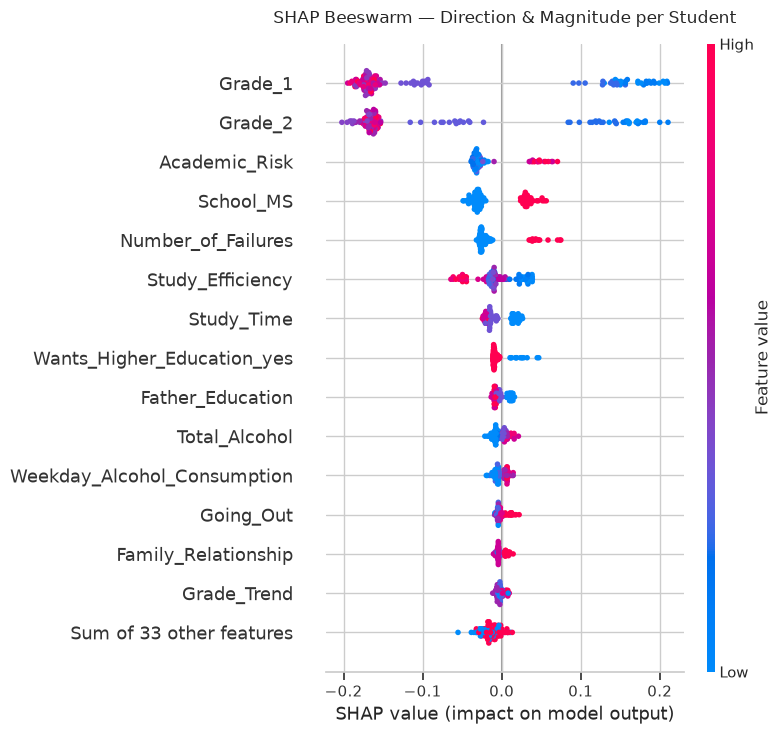

In [174]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Direction & Magnitude per Student', pad=15)
plt.tight_layout()
plt.show()


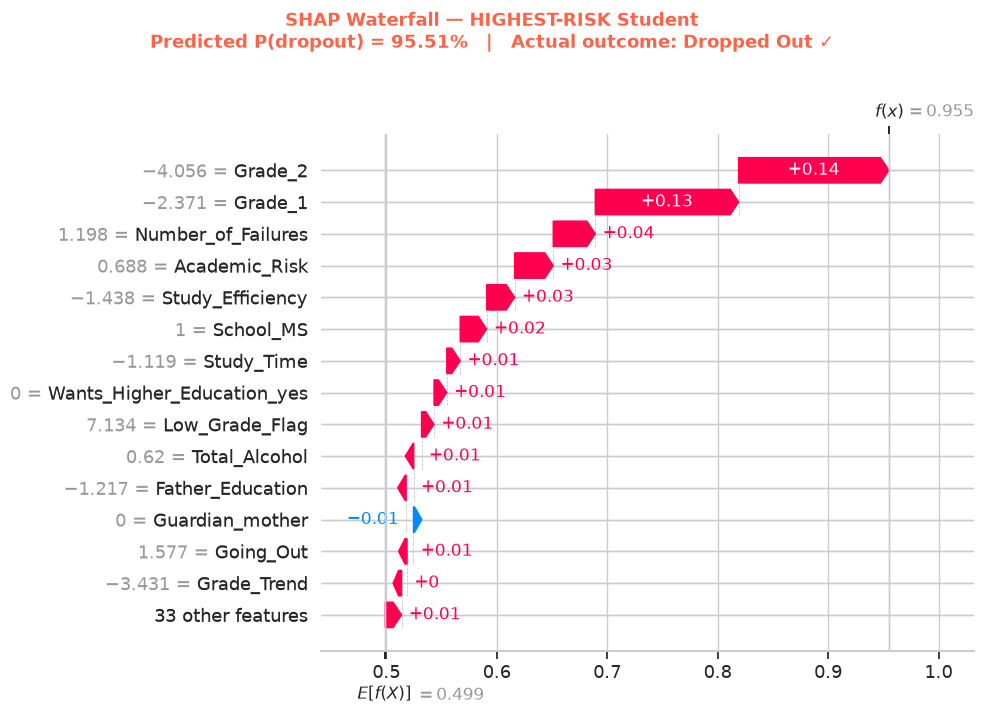

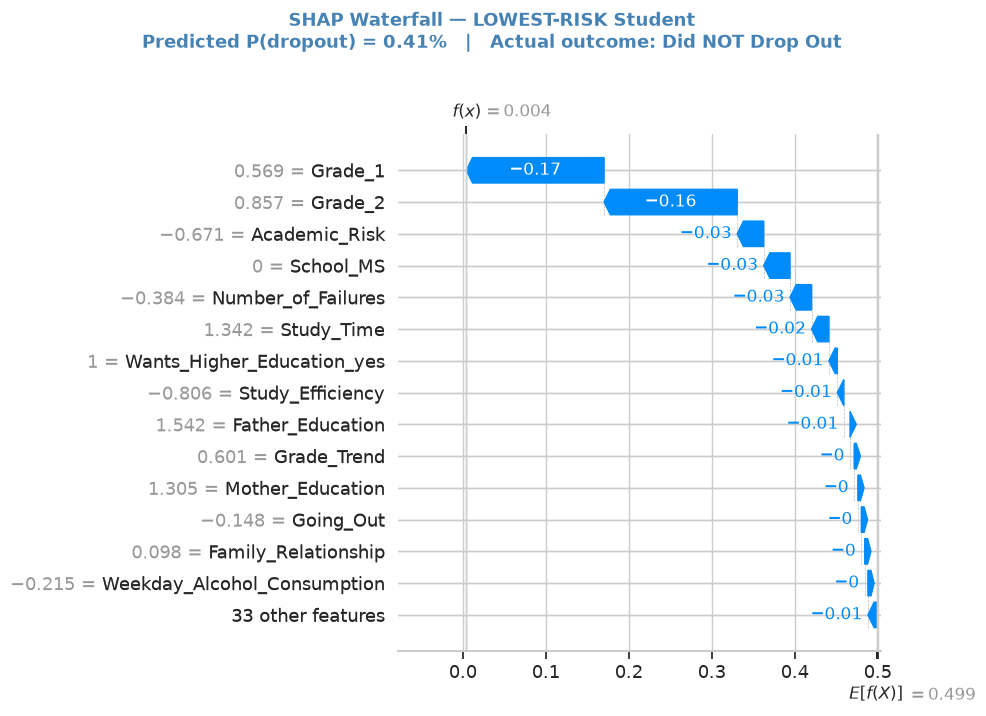


Top contributing features — comparison:

                            SHAP (High-Risk)  SHAP (Low-Risk)
Feature                                                      
Grade_2                                0.136           -0.160
Grade_1                                0.130           -0.166
Number_of_Failures                     0.038           -0.026
Academic_Risk                          0.035           -0.032
Study_Efficiency                       0.025           -0.008
School_MS                              0.024           -0.032
Study_Time                             0.012           -0.021
Wants_Higher_Education_yes             0.012           -0.010


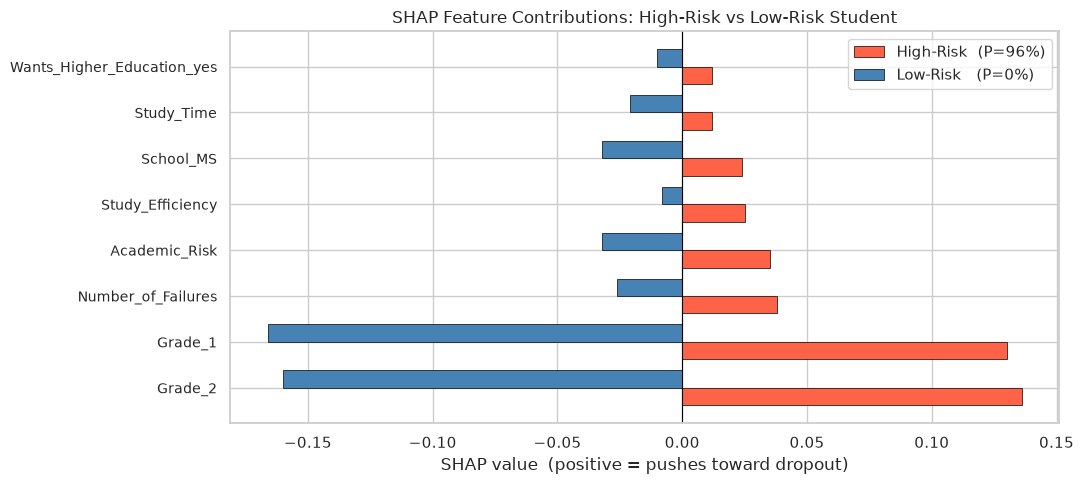

In [175]:

high_risk_idx = int(np.argmax(y_prob))
low_risk_idx  = int(np.argmin(y_prob))

for idx, label, color in [
    (high_risk_idx, 'HIGHEST-RISK', 'tomato'),
    (low_risk_idx,  'LOWEST-RISK',  'steelblue'),
]:
    actual    = 'Dropped Out ✓' if y_test.iloc[idx] == 1 else 'Did NOT Drop Out'
    prob      = y_prob[idx]

    # SHAP waterfall must own its own figure — subplots don't work
    shap.plots.waterfall(shap_values[idx], max_display=15, show=False)

    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    fig.suptitle(
        f'SHAP Waterfall — {label} Student\n'
        f'Predicted P(dropout) = {prob:.2%}   |   Actual outcome: {actual}',
        fontsize=13, fontweight='bold', color=color, y=1.02
    )
    plt.tight_layout()
    plt.show()

# ── Side-by-side SHAP value comparison (top features only) ───────────────────
print('\nTop contributing features — comparison:\n')
sv_high = shap_values.values[high_risk_idx]
sv_low  = shap_values.values[low_risk_idx]

# Union of top-8 features from either student
top_idx = np.union1d(
    np.argsort(np.abs(sv_high))[::-1][:8],
    np.argsort(np.abs(sv_low))[::-1][:8]
)

cmp_df = pd.DataFrame({
    'Feature':          [feature_names[i] for i in top_idx],
    'SHAP (High-Risk)': sv_high[top_idx].round(3),
    'SHAP (Low-Risk)':  sv_low[top_idx].round(3),
}).set_index('Feature').sort_values('SHAP (High-Risk)', ascending=False)

print(cmp_df.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
x   = np.arange(len(cmp_df))
w   = 0.38
ax.barh(x - w/2, cmp_df['SHAP (High-Risk)'], w, label=f'High-Risk  (P={y_prob[high_risk_idx]:.0%})', color='tomato',    edgecolor='black', linewidth=0.5)
ax.barh(x + w/2, cmp_df['SHAP (Low-Risk)'],  w, label=f'Low-Risk   (P={y_prob[low_risk_idx]:.0%})',  color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_yticks(x)
ax.set_yticklabels(cmp_df.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value  (positive = pushes toward dropout)')
ax.set_title('SHAP Feature Contributions: High-Risk vs Low-Risk Student')
ax.legend()
plt.tight_layout()
plt.show()


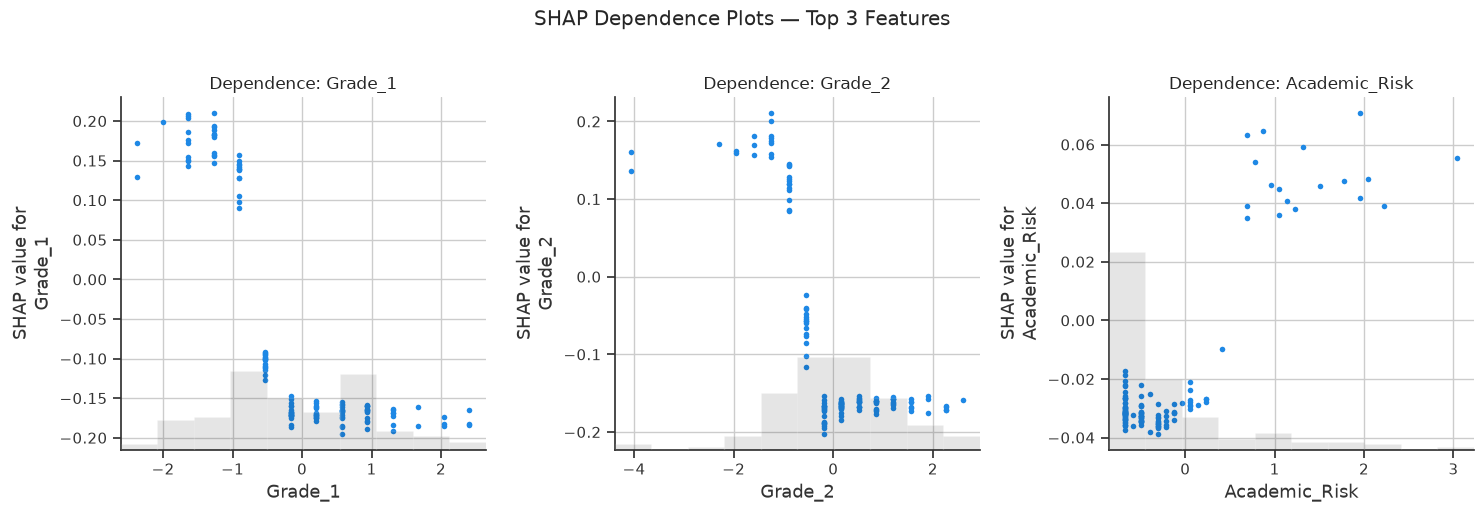

In [176]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]

fig, axes = plt.subplots(1, len(top3_idx), figsize=(5 * len(top3_idx), 5))
if len(top3_idx) == 1:
    axes = [axes]

for ax, feat_idx in zip(axes, top3_idx):
    shap.plots.scatter(shap_values[:, feat_idx], ax=ax, show=False)
    ax.set_title(f'Dependence: {feature_names[feat_idx]}')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', y=1.02)
plt.tight_layout()
plt.show()


## 12. Explainability — LIME

LIME provides a second local explanation for individual predictions. It fits a simple model around one student at a time and shows which processed features influenced that local decision.

SHAP is used as the main explanation method, while LIME is included as a supporting check.


In [177]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=feature_names,
    class_names=['Not Dropped Out', 'Dropped Out'],
    mode='classification',
    random_state=42
)
print('LIME explainer ready.')

LIME explainer ready.


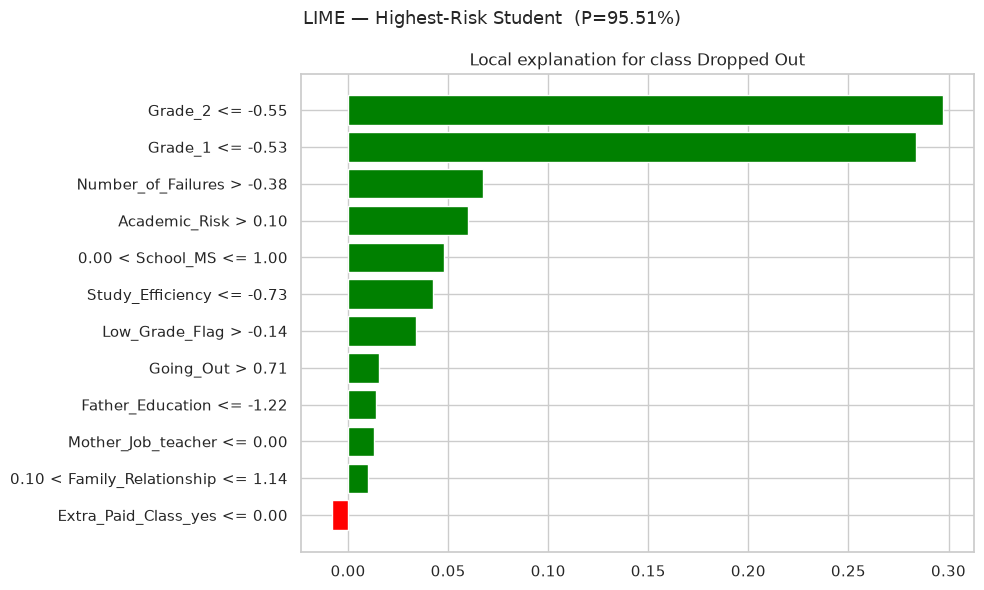

In [178]:
exp_high = lime_explainer.explain_instance(
    data_row=X_test_proc[high_risk_idx],
    predict_fn=final_model.predict_proba,
    num_features=12, labels=[1]
)
fig = exp_high.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
fig.suptitle(f'LIME — Highest-Risk Student  (P={y_prob[high_risk_idx]:.2%})', fontsize=13)
plt.tight_layout()
plt.show()

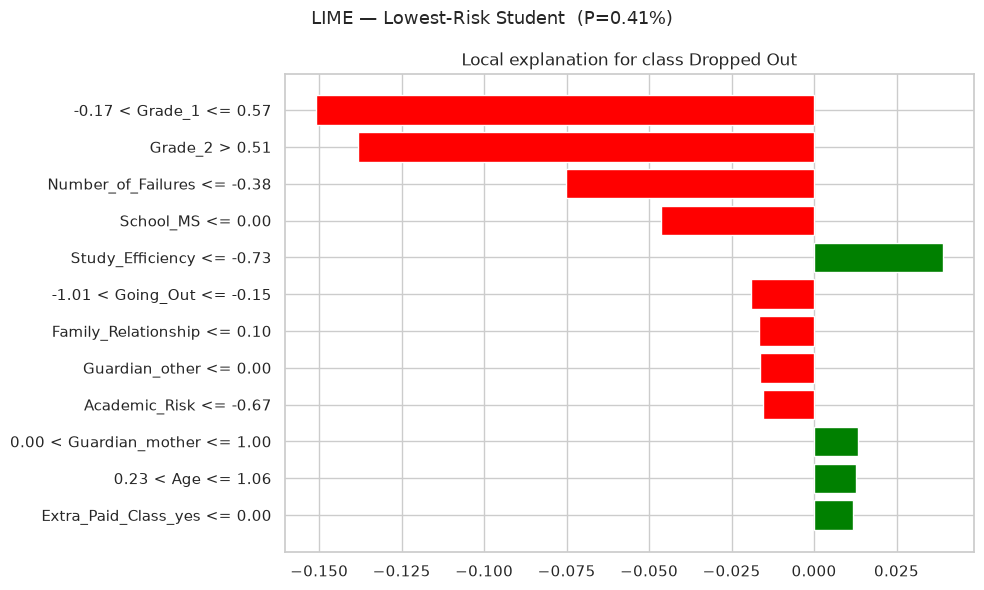

In [179]:
exp_low = lime_explainer.explain_instance(
    data_row=X_test_proc[low_risk_idx],
    predict_fn=final_model.predict_proba,
    num_features=12, labels=[1]
)
fig = exp_low.as_pyplot_figure(label=1)
fig.set_size_inches(10, 6)
fig.suptitle(f'LIME — Lowest-Risk Student  (P={y_prob[low_risk_idx]:.2%})', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Risk Scoring & Interventions

Final risk scoring uses calibrated dropout probabilities and the calibrated F2 threshold.

- **LOW**: below the calibrated decision threshold
- **MEDIUM**: at or above the calibrated threshold but below the high-risk cutoff
- **HIGH**: at or above the high-risk cutoff

The high-risk cutoff is set to at least 0.65 so that the highest tier remains reserved for students with clearly elevated calibrated risk. For high-risk students, the strongest SHAP risk drivers are mapped to practical intervention suggestions.


Risk Tier Distribution:
Risk_Tier
LOW       99
HIGH      22
MEDIUM     9
Name: count, dtype: int64


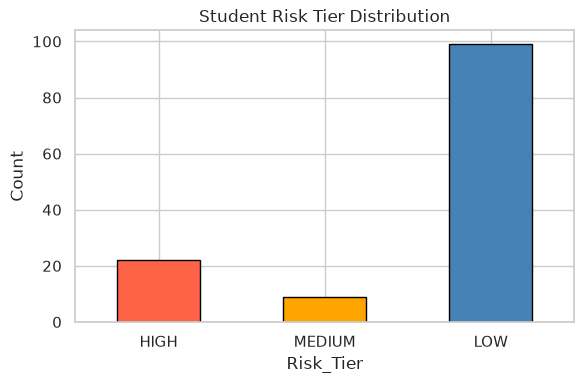

In [180]:
high_risk_threshold = max(0.65, float(best_thr_cal))

def assign_risk_tier(prob):
    if prob >= high_risk_threshold:
        return 'HIGH'
    elif prob >= best_thr_cal:
        return 'MEDIUM'
    else:
        return 'LOW'

results_df = X_test.copy().reset_index(drop=True)
results_df['Actual_Dropout'] = y_test.values
results_df['Dropout_Prob_Calibrated'] = y_prob_cal
results_df['Predicted_Dropout'] = y_pred_cal
results_df['Risk_Tier'] = [assign_risk_tier(p) for p in y_prob_cal]

print('Risk Tier Distribution:')
print(results_df['Risk_Tier'].value_counts())

tier_counts = results_df['Risk_Tier'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'HIGH': 'tomato', 'MEDIUM': 'orange', 'LOW': 'steelblue'}
tier_counts.reindex(['HIGH','MEDIUM','LOW']).fillna(0).plot(
    kind='bar', ax=ax, color=[colors[t] for t in ['HIGH','MEDIUM','LOW']], edgecolor='black'
)
ax.set_title('Student Risk Tier Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(['HIGH', 'MEDIUM', 'LOW'], rotation=0)
plt.tight_layout()
plt.show()


In [181]:
# SHAP driver table for high-risk students
high_risk_rows = results_df[results_df['Risk_Tier'] == 'HIGH'].index.tolist()
driver_records = []
for row_idx in high_risk_rows[:10]:
    sv  = shap_values.values[row_idx]
    top = np.argsort(sv)[::-1][:5]
    drivers = ', '.join([f'{feature_names[i]} ({sv[i]:+.2f})' for i in top])
    driver_records.append({
        'Student_Index': row_idx,
        'Dropout_Prob_Calibrated':  round(y_prob_cal[row_idx], 3),
        'Actual':        int(y_test.iloc[row_idx]),
        'Top_Risk_Drivers': drivers
    })

pd.set_option('display.max_colwidth', 120)
pd.DataFrame(driver_records)


,Student_Index,Dropout_Prob_Calibrated,Actual,Top_Risk_Drivers
0,5,0.702,0,"Grade_2 (+0.12), Grade_1 (+0.11), Number_of_Failures (+0.05), Academic_Risk (+0.04), Study_Time (+0.02)"
1,7,0.837,1,"Grade_1 (+0.15), Grade_2 (+0.15), Academic_Risk (+0.06), Number_of_Failures (+0.05), Wants_Higher_Education_yes (+0.02)"
2,8,0.693,1,"Grade_1 (+0.21), Grade_2 (+0.20), Study_Efficiency (+0.03), Address_U (+0.00), Going_Out (+0.00)"
3,14,0.864,1,"Grade_2 (+0.16), Grade_1 (+0.15), Number_of_Failures (+0.05), Academic_Risk (+0.05), Study_Efficiency (+0.04)"
4,25,0.748,1,"Grade_1 (+0.18), Grade_2 (+0.17), Study_Efficiency (+0.03), Wants_Higher_Education_yes (+0.02), Father_Education (+0..."
5,31,0.768,0,"Grade_2 (+0.16), Grade_1 (+0.10), Academic_Risk (+0.05), Number_of_Failures (+0.04), Study_Time (+0.02)"
6,48,0.727,1,"Grade_1 (+0.14), Grade_2 (+0.08), Number_of_Failures (+0.04), Academic_Risk (+0.04), Study_Efficiency (+0.03)"
7,51,0.868,1,"Grade_2 (+0.16), Grade_1 (+0.15), Academic_Risk (+0.05), Number_of_Failures (+0.04), Study_Efficiency (+0.03)"
8,56,0.796,1,"Grade_1 (+0.17), Grade_2 (+0.16), Study_Efficiency (+0.03), School_MS (+0.03), Wants_Higher_Education_yes (+0.02)"
9,60,0.760,1,"Grade_1 (+0.19), Grade_2 (+0.18), Study_Efficiency (+0.03), School_MS (+0.03), Father_Education (+0.01)"


### Intervention Recommendations per Student

The recommendation rules are simple and transparent. A recommendation is shown only when a top SHAP risk driver also meets a clear condition, such as low grades, high absences, multiple failures, or no stated plan for higher education.


In [182]:

# ── Intervention rule table ────────────────────────────────────────────────────
# Maps each feature (after preprocessing name) to: condition + action
INTERVENTIONS = {
    'Grade_1': {
        'check': lambda val: val <= 8,
        'message': 'Very low Grade 1 — assign a peer tutor immediately before semester 2 begins.'
    },
    'Grade_2': {
        'check': lambda val: val <= 8,
        'message': 'Very low Grade 2 — schedule urgent academic support; consider remedial classes.'
    },
    'Grade_Trend': {
        'check': lambda val: val < -2,
        'message': 'Grades declining significantly — investigate cause (personal, health, social) with a counselor.'
    },
    'Low_Grade_Flag': {
        'check': lambda val: val == 1,
        'message': 'Student scored ≤5 in at least one semester — flag for intensive academic intervention.'
    },
    'Number_of_Absences': {
        'check': lambda val: val > 10,
        'message': 'High absenteeism — contact parents, set up an attendance monitoring plan.'
    },
    'Number_of_Failures': {
        'check': lambda val: val >= 2,
        'message': '2+ subject failures — refer to remedial class and set monthly progress reviews.'
    },
    'Study_Time': {
        'check': lambda val: val <= 1,
        'message': 'Very low study time — enroll in structured study skills workshop.'
    },
    'Total_Alcohol': {
        'check': lambda val: val >= 6,
        'message': 'High combined alcohol consumption — refer to school counselor for welfare check.'
    },
    'Wants_Higher_Education': {
        'check': lambda val: str(val).strip().lower() == 'no',
        'message': 'No aspiration for higher education — provide career counseling and motivational support.'
    },
    'Academic_Risk': {
        'check': lambda val: val >= 3,
        'message': 'High combined Academic Risk score (failures + absences) — prioritise for weekly check-ins.'
    },
    'Health_Status': {
        'check': lambda val: val <= 2,
        'message': 'Poor self-reported health — connect with school health services.'
    },
    'Family_Relationship': {
        'check': lambda val: val <= 2,
        'message': 'Poor family relationships — involve school social worker or family support programme.'
    },
    'Going_Out': {
        'check': lambda val: val >= 4,
        'message': 'Spending a lot of time going out — discuss time management and study-life balance.'
    },
}

def get_interventions(student_raw, shap_vals, feature_names, top_n=5):
    """
    For a single student, return SHAP-ranked list of (driver, intervention).
    Only returns interventions where the feature condition is actually triggered.
    """
    top_shap_idx = np.argsort(shap_vals)[::-1][:top_n]
    recommendations = []

    for i in top_shap_idx:
        feat_full = feature_names[i]
        shap_val  = shap_vals[i]
        if shap_val <= 0:
            continue  # only show risk-increasing factors

        # Match to base feature name (OHE adds suffixes like _no, _yes)
        matched_feat = None
        matched_raw  = None
        for feat, rule in INTERVENTIONS.items():
            if feat_full.startswith(feat) or feat_full == feat:
                matched_feat = feat
                matched_raw  = student_raw.get(feat, None)
                break

        if matched_feat is None or matched_raw is None:
            continue

        try:
            if INTERVENTIONS[matched_feat]['check'](matched_raw):
                recommendations.append({
                    'Feature':       matched_feat,
                    'Value':         matched_raw,
                    'SHAP':          float(round(float(shap_val), 3)),
                    'Action':        INTERVENTIONS[matched_feat]['message'],
                })
        except Exception:
            continue

    return recommendations

# ── Apply to top high-risk students ───────────────────────────────────────────
high_risk_students = results_df[results_df['Risk_Tier'] == 'HIGH'].head(5)
sep = '=' * 70

for _, row in high_risk_students.iterrows():
    idx       = row.name
    prob      = row['Dropout_Prob_Calibrated']
    actual    = 'Actual DROPOUT' if row['Actual_Dropout'] == 1 else 'Did not drop out'
    sv        = shap_values.values[idx]
    raw_feats = X_test.reset_index(drop=True).iloc[idx].to_dict()

    print(sep)
    print(f'Student #{idx}  |  Risk: HIGH  |  P(dropout) = {prob:.1%}  |  {actual}')
    print(sep)

    recs = get_interventions(raw_feats, sv, feature_names, top_n=8)
    if not recs:
        print('  No specific interventions triggered by top SHAP features.')
    else:
        for r in recs:
            print(f'  [{r["Feature"]} = {r["Value"]}  |  SHAP +{r["SHAP"]}]')
            print(f'    → {r["Action"]}')
            print()


Student #5  |  Risk: HIGH  |  P(dropout) = 70.2%  |  Did not drop out
  [Academic_Risk = 3.8  |  SHAP +0.045]
    → High combined Academic Risk score (failures + absences) — prioritise for weekly check-ins.

  [Study_Time = 1  |  SHAP +0.022]
    → Very low study time — enroll in structured study skills workshop.

  [Going_Out = 5  |  SHAP +0.009]
    → Spending a lot of time going out — discuss time management and study-life balance.

  [Total_Alcohol = 6  |  SHAP +0.004]
    → High combined alcohol consumption — refer to school counselor for welfare check.

Student #7  |  Risk: HIGH  |  P(dropout) = 83.7%  |  Actual DROPOUT
  [Grade_1 = 7  |  SHAP +0.154]
    → Very low Grade 1 — assign a peer tutor immediately before semester 2 begins.

  [Grade_2 = 8  |  SHAP +0.154]
    → Very low Grade 2 — schedule urgent academic support; consider remedial classes.

  [Academic_Risk = 8.2  |  SHAP +0.055]
    → High combined Academic Risk score (failures + absences) — prioritise for weekly check

In [183]:
def predict_student_risk(student_dict: dict, top_n: int = 5):
    """Given a raw student record, return calibrated risk probability, tier, and SHAP factors."""
    student_df = engineer_features(pd.DataFrame([student_dict]))

    for col in X.columns:
        if col not in student_df.columns:
            # Use 'unknown' for categoricals so OHE (handle_unknown='ignore') zeroes it out cleanly.
            # Use 0 for numericals as a neutral default.
            student_df[col] = 'unknown' if col in categorical_cols else 0
    student_df = student_df[X.columns]

    for col in categorical_cols:
        if col in student_df.columns:
            student_df[col] = student_df[col].astype(str)

    prob = calibrated_pipeline.predict_proba(student_df)[0, 1]
    tier = assign_risk_tier(prob)
    predicted_at_risk = bool(prob >= best_thr_cal)

    student_proc = final_pipeline.named_steps['preprocessor'].transform(student_df)
    student_df_proc = pd.DataFrame(np.asarray(student_proc), columns=feature_names)
    student_shap_raw = explainer_shap(student_df_proc)
    sv = np.asarray(student_shap_raw.values)[0]

    # Some classifiers return one SHAP value per class. Use class 1: dropout / at-risk.
    if sv.ndim == 2:
        sv = sv[:, 1]

    print(f'Calibrated Dropout Probability : {prob:.2%}')
    print(f'Calibrated Decision Threshold  : {best_thr_cal:.2%}')
    print(f'Predicted At Risk              : {predicted_at_risk}')
    print(f'Risk Tier                      : {tier}')
    print(f'\nTop {top_n} Risk-Increasing Factors:')
    for i in np.argsort(sv)[::-1][:top_n]:
        print(f'  {feature_names[i]:40s}  SHAP={sv[i]:+.4f}')

    print(f'\nTop {top_n} Protective Factors:')
    for i in np.argsort(sv)[:top_n]:
        print(f'  {feature_names[i]:40s}  SHAP={sv[i]:+.4f}')

    recommendations = get_interventions(student_df.iloc[0].to_dict(), sv, feature_names, top_n=top_n)
    if recommendations:
        print('\nRecommended Actions:')
        for rec in recommendations:
            print(f'  [{rec["Feature"]} = {rec["Value"]} | SHAP +{rec["SHAP"]}]')
            print(f'    {rec["Action"]}')

    return {
        'calibrated_probability': float(prob),
        'decision_threshold': float(best_thr_cal),
        'predicted_at_risk': predicted_at_risk,
        'tier': tier,
        'top_risk_factors': [feature_names[i] for i in np.argsort(sv)[::-1][:top_n]],
        'recommendations': recommendations,
    }


In [184]:
# Demo: high-risk student profile
sample_student = X.iloc[0].to_dict()
sample_student.update({
    'Number_of_Absences':        20,
    'Number_of_Failures':         3,
    'Study_Time':                 1,
    'Grade_1':                    4,
    'Grade_2':                    3,
    'Weekday_Alcohol_Consumption': 5,
    'Wants_Higher_Education':    'no',
})
result = predict_student_risk(sample_student)

Calibrated Dropout Probability : 83.76%
Calibrated Decision Threshold  : 30.51%
Predicted At Risk              : True
Risk Tier                      : HIGH

Top 5 Risk-Increasing Factors:
  Grade_1                                   SHAP=+0.1511
  Grade_2                                   SHAP=+0.1486
  Academic_Risk                             SHAP=+0.0451
  Number_of_Failures                        SHAP=+0.0396
  Study_Efficiency                          SHAP=+0.0237

Top 5 Protective Factors:
  School_MS                                 SHAP=-0.0257
  Father_Education                          SHAP=-0.0076
  Mother_Education                          SHAP=-0.0053
  Number_of_Absences                        SHAP=-0.0037
  Family_Relationship                       SHAP=-0.0035

Recommended Actions:
  [Grade_1 = 4 | SHAP +0.151]
    Very low Grade 1 — assign a peer tutor immediately before semester 2 begins.
  [Grade_2 = 3 | SHAP +0.149]
    Very low Grade 2 — schedule urgent academic supp

## Summary

| Step | Approach | Reason |
|---|---|---|
| Leakage fix | Removed `Final_Grade` | It is known after the prediction point and leaks target information |
| Feature engineering | Created academic, attendance, family, and study-behaviour features | Capture useful early-warning patterns without using final outcomes |
| Base model screening | Compared model families by cross-validated F2-score | Shortlist the strongest candidates while prioritising recall |
| Imbalance selection | Tested class weighting and SMOTENC for the top two models | Select the best complete pipeline, not the model and imbalance method separately |
| Tuning | Tuned the selected pipeline with Optuna | Improve the chosen workflow without changing the validation logic |
| Thresholding | Selected thresholds on validation data | Match the decision rule to the recall-focused objective |
| Calibration | Used Platt scaling and selected `best_thr_cal` | Use calibrated probabilities with a threshold on the same probability scale |
| Fairness check | Reported subgroup recall and false-negative rates | Identify groups where the model may need closer review |
| Explainability | Used SHAP and LIME | Explain why individual students are flagged as higher risk |
| Interventions | Mapped top risk drivers to simple actions | Make predictions useful for counselling or academic support |

### Main Interpretation
- Early grades and grade decline are the strongest academic warning signals.
- Failures and absences are important risk indicators.
- The final model should be used as decision support, not as an automatic decision-maker.
- High-risk predictions should be reviewed by a human before any intervention is made.


## 14. Model Persistence

Save the calibrated pipeline and supporting artifacts so the model can be loaded and used for predictions without re-running the notebook.

In [185]:
import joblib, os

save_dir = 'model_artifacts'
os.makedirs(save_dir, exist_ok=True)

# calibrated_pipeline is the primary artifact for making predictions.
# final_pipeline is kept separately for SHAP/LIME (requires the unfitted preprocessor).
joblib.dump(calibrated_pipeline, os.path.join(save_dir, 'calibrated_pipeline.joblib'))
joblib.dump(final_pipeline,      os.path.join(save_dir, 'final_pipeline.joblib'))
joblib.dump({
    'best_thr':          best_thr,
    'best_thr_cal':      best_thr_cal,
    'high_risk_threshold': high_risk_threshold,
    'feature_names':     feature_names,
    'categorical_cols':  categorical_cols,
    'numerical_cols':    numerical_cols,
    'model_name':        best_tuned_model_name,
    'imbalance':         best_tuned_imbalance,
    'cv_f2':             best_tuned_cv_f2,
}, os.path.join(save_dir, 'metadata.joblib'))

print(f'Saved to {save_dir}/')
print(f'  calibrated_pipeline.joblib  — use for predict_student_risk()')
print(f'  final_pipeline.joblib       — base pipeline for SHAP/LIME')
print(f'  metadata.joblib             — thresholds, feature names, model info')
print()
print(f'To reload:')
print(f'  import joblib')
print(f'  calibrated_pipeline = joblib.load("{save_dir}/calibrated_pipeline.joblib")')
print(f'  meta = joblib.load("{save_dir}/metadata.joblib")')
print(f'  best_thr_cal = meta["best_thr_cal"]')


Saved to model_artifacts/
  calibrated_pipeline.joblib  — use for predict_student_risk()
  final_pipeline.joblib       — base pipeline for SHAP/LIME
  metadata.joblib             — thresholds, feature names, model info

To reload:
  import joblib
  calibrated_pipeline = joblib.load("model_artifacts/calibrated_pipeline.joblib")
  meta = joblib.load("model_artifacts/metadata.joblib")
  best_thr_cal = meta["best_thr_cal"]
